# Section 3.6. Permutation Arrays and Modern Schubert Problems.

functions included:<br>

posetDiagram(n,d,show=True) <br>
    > returns a poset of the elements in [n]^d. <br>
    > If show is specified, True prints the Hasse diagram and False does not <br>
getPy(tup_poset,P,y,printQ=False) <br>
    > gets P[y] for a specified set of tuples P and a "reference tuple" y <br>
    > If printQ is specified, True prints "P[y] = ..." and False does not <br>
isRankable(P) <br>
    > If rankable, returns the rank
    > Else returns 'False' as a string
isTotallyRankable(P) <br>
makeRankArray(P,tup_poset,n,d) <br>
    > only prints nicely for d=3

In [1]:
import itertools

In [2]:
def posetDiagram(n,d,show=True):
    tuples = []
    for tup in itertools.product(range(1, n+1), repeat=d):
        tuples.append(tup)
    
    relations = []
    for pair in itertools.combinations_with_replacement(tuples,2):
        less_than = True
        for i in range(0,d):
            if pair[0][i] > pair[1][i]:
                less_than = False
            else:
                pass
        if less_than == True:
            # print(f"{pair[0]} is less than {pair[1]}")
            relations.append([pair[0],pair[1]])
        else:
            # print(f"{pair[0]} is greater than or equal to {pair[1]}")
            pass

    P = Poset((tuples,relations))
    if show==True:
        P.show()

    return P

In [3]:
def getPy(tup_poset,P,y,printQ=False):
    Py = []
    for tup in P:
        if tup_poset.is_lequal(tup,y):
            Py.append(tup)
    if printQ == True:
        print(f"P[y] = {Py}")
    return Py

In [4]:
def isRankable(P):
    if P == []:
        return 0
    ranks = []
    for i in range(len(P[0])):
        digits = []
        for tup in P:
            digits.append(tup[i])
        ranks.append(len(list(set(digits))))
    if len(list(set(ranks))) == 1:
        rankable = ranks[0]
    else:
        rankable = "False"
    return rankable

In [5]:
def isTotallyRankable(P,tup_poset):
    totRankable = True
    for y in tup_poset:
        Py = getPy(tup_poset,P,y);
        if isRankable(Py) == "False":
            totRankable = False
            break
        else:
            pass
    return totRankable

In [18]:
# Used ChatGPT-5.3 to help with this
def makeRankArray(P,tup_poset,n,d):
    tuples = itertools.product(range(n), repeat=d)
    A = {idx: 0 for idx in tuples}
    tuples = itertools.product(range(n), repeat=d)
    for tup in tuples:
        # the tuples get created with elements [0,n-1] instead of [1,n] so shift them all up 1
        y = tuple(x + 1 for x in tup)
        # print(f"y = {y}")
        Py = getPy(tup_poset,P,y)
        # print(f"P[y] = {Py}")
        rk = isRankable(Py)
        # print(f"rkP[{y}] = {rk}")
        A[tup] = rk
        
    if d==3:
        for k in range(n):
            print(f"Slice {k+1}")
            
            M = matrix([
                [A[(i,j,k)] for j in range(n)]
                for i in range(n)
            ])
            
            print(M)
            print()
    else:
        print(A)

## Examples to test the code with

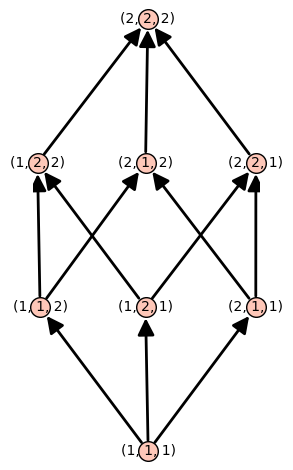

In [7]:
posetDiagram(2,3);

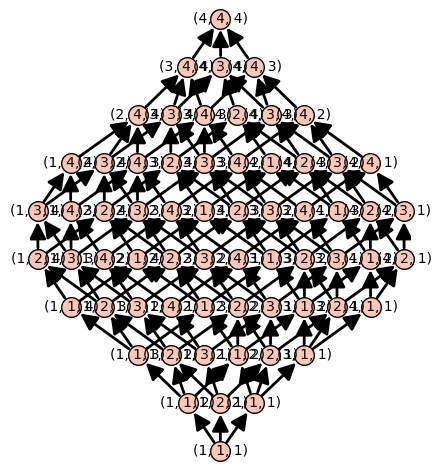

In [8]:
posetDiagram(4,3);

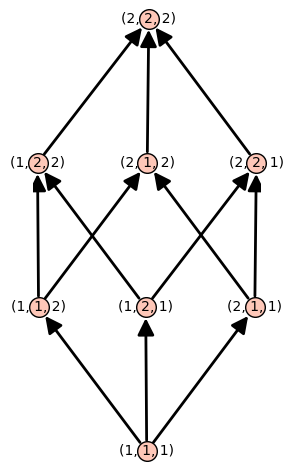

P[y] = [(1, 2, 1), (1, 1, 2)]


In [9]:
tup_poset = posetDiagram(2,3);
P = [(2,2,1),(1,2,1),(1,1,2)]
y = (1,2,2)
getPy(tup_poset,P,y,True);

## Examples from the paper

In [10]:
# Example 3.57. The array Q = {(1, 2), (2, 2)} ⊆ [2]2 is not rankable since rk1(Q) = 2 and rk2(Q) = 1.
Q = [(1,2),(2,2)]
isRankable(Q)

'False'

In [11]:
#Example 3.58. For example with n = 4, d = 3, the following subset of [4]3 is a totally rankable dot array:
# P = {(3, 4, 1), (4, 2, 2), (1, 4, 3), (3, 3, 3), (2, 3, 4), (3, 2, 4), (4, 1, 4)}.
P = [(3, 4, 1), (4, 2, 2), (1, 4, 3), (3, 3, 3), (2, 3, 4), (3, 2, 4), (4, 1, 4)]
isRankable(P)

4

In [12]:
%%time
# Example 3.59.

tup_poset = posetDiagram(4,3,False);
P = [(3,4,1),(4,2,2),(1,4,3),(3,3,3),(2,3,4),(3,2,4),(4,1,4)]
A = [(3, 4, 1), (4, 2, 2), (2, 3, 4)]
B = [(3, 4, 1), (4, 2, 2), (1, 4, 3)]
print(f"P is totally rankable: {isTotallyRankable(P,tup_poset)}")
print(f"A is totally rankable: {isTotallyRankable(A,tup_poset)}") # totally rankable
print(f"B is totally rankable: {isTotallyRankable(B,tup_poset)}") # not totally rankable
print(f"B[4,4,4] is rankable: {isRankable(getPy(tup_poset,B,(4,4,4)))}") # not rankable

P is totally rankable: True
A is totally rankable: True
B is totally rankable: False
B[4,4,4] is rankable: False
CPU times: user 10.5 ms, sys: 214 μs, total: 10.7 ms
Wall time: 10.7 ms


In [17]:
makeRankArray(P,tup_poset,4,3)

Slice 1
[0 0 0 0]
[0 0 0 0]
[0 0 0 1]
[0 0 0 1]

Slice 2
[0 0 0 0]
[0 0 0 0]
[0 0 0 1]
[0 1 1 2]

Slice 3
[0 0 0 1]
[0 0 0 1]
[0 0 1 2]
[0 1 2 3]

Slice 4
[0 0 0 1]
[0 0 1 2]
[0 1 2 3]
[1 2 3 4]

